In [1]:
from datasets import load_dataset

In [2]:
dataset = load_dataset('starvector/text2svg-stack')

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg', 'caption_blip2', 'caption_cogvlm', 'caption_llava'],
        num_rows: 2169710
    })
    test: Dataset({
        features: ['Filename', 'Svg', 'caption_blip2', 'caption_cogvlm', 'caption_llava'],
        num_rows: 5709
    })
})

In [5]:
import random

def show_one_example(dataset, split='train'):
    """Displays one random example from the given dataset split."""
    if split not in dataset:
        raise ValueError("Invalid split. Choose from: " + ", ".join(dataset.keys()))
    
    example = random.choice(dataset[split])
    
    for key, value in example.items():
        print(f"{key}: {value}\n")
    
    return example


In [ ]:
show_one_example(dataset, split='train')

Filename: 90694ff888d95b9f74ebb752fef4b687de8e51b1.svg

Svg: <svg xmlns="http://www.w3.org/2000/svg" width="500" height="420" version="1.0" id="ezcGraph"><defs/><g id="ezcGraphChart" color-rendering="optimizeQuality" shape-rendering="geometricPrecision" text-rendering="optimizeLegibility"><path d=" M 0.0000,420.0000 L 0.0000,0.0000 L 500.0000,0.0000 L 500.0000,420.0000 L 0.0000,420.0000 z " style="fill: #eeeeec; fill-opacity: 1.00; stroke: none;" id="ezcGraphPolygon_1"/><path d=" M 0.0000,42.0000 L 0.0000,0.0000 L 500.0000,0.0000 L 500.0000,42.0000 L 0.0000,42.0000 z " style="fill: #000000; fill-opacity: 0.00; stroke: none;" id="ezcGraphPolygon_2"/><path d="M 261.49,235.92 L 373.99,235.92 A 112.50,112.50 0 0,1 339.16,317.30 z" style="fill: #3465a4; fill-opacity: 1.00; stroke: none; cursor: pointer;" id="ezcGraphCircleSector_4" onclick="top.location = 'http://127.0.0.1/linux-hardware.org/index.php?view=computers&amp;type=desktop&amp;f=cpu_microarch&amp;v=Zen+2&amp;p=-1'"/><path d="M 262

{'Filename': '90694ff888d95b9f74ebb752fef4b687de8e51b1.svg',
 'Svg': '<svg xmlns="http://www.w3.org/2000/svg" width="500" height="420" version="1.0" id="ezcGraph"><defs/><g id="ezcGraphChart" color-rendering="optimizeQuality" shape-rendering="geometricPrecision" text-rendering="optimizeLegibility"><path d=" M 0.0000,420.0000 L 0.0000,0.0000 L 500.0000,0.0000 L 500.0000,420.0000 L 0.0000,420.0000 z " style="fill: #eeeeec; fill-opacity: 1.00; stroke: none;" id="ezcGraphPolygon_1"/><path d=" M 0.0000,42.0000 L 0.0000,0.0000 L 500.0000,0.0000 L 500.0000,42.0000 L 0.0000,42.0000 z " style="fill: #000000; fill-opacity: 0.00; stroke: none;" id="ezcGraphPolygon_2"/><path d="M 261.49,235.92 L 373.99,235.92 A 112.50,112.50 0 0,1 339.16,317.30 z" style="fill: #3465a4; fill-opacity: 1.00; stroke: none; cursor: pointer;" id="ezcGraphCircleSector_4" onclick="top.location = \'http://127.0.0.1/linux-hardware.org/index.php?view=computers&amp;type=desktop&amp;f=cpu_microarch&amp;v=Zen+2&amp;p=-1\'"/><pa

In [38]:
from datasets import DatasetDict

def preprocess_data(hf_dataset):
    """ 
    Preprocess dataset by:
    - Keeping only relevant columns
    - Renaming columns
    - Filtering descriptions by length and starting word
    """

    # Remove unnecessary columns
    reduced_dataset = hf_dataset.remove_columns(["caption_blip2", "caption_cogvlm"])

    # Rename columns for consistency
    renamed_dataset = reduced_dataset.rename_columns({
        "Filename": "filename",
        "Svg": "svg",
        "caption_llava": "description"
    })

    # Define filtering criteria
    def filter_description(example):
        description = example["description"]
        first_word = description.split()[0].lower() if description else ""
        
        # Only keep descriptions that start with specified words and are <= 200 characters
        valid_start = first_word in {"a", "an", "two", "three"}
        valid_length = len(description) <= 200
        
        return valid_start and valid_length

    # Apply filtering
    preprocessed_data = renamed_dataset.filter(filter_description)
    
    return preprocessed_data


In [39]:
preprocessed_dataset = preprocess_data(dataset)

Filter:   0%|          | 0/2169710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5709 [00:00<?, ? examples/s]

In [40]:
preprocessed_dataset

DatasetDict({
    train: Dataset({
        features: ['filename', 'svg', 'description'],
        num_rows: 1521033
    })
    test: Dataset({
        features: ['filename', 'svg', 'description'],
        num_rows: 3950
    })
})

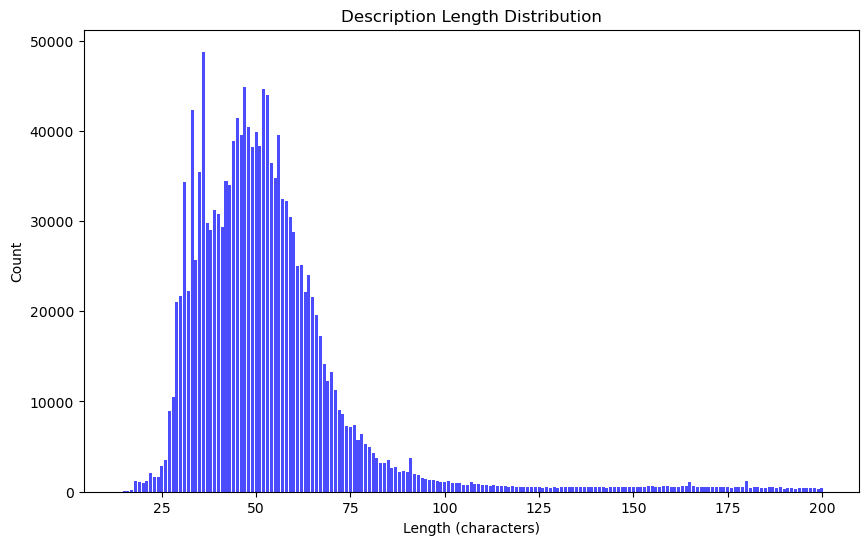

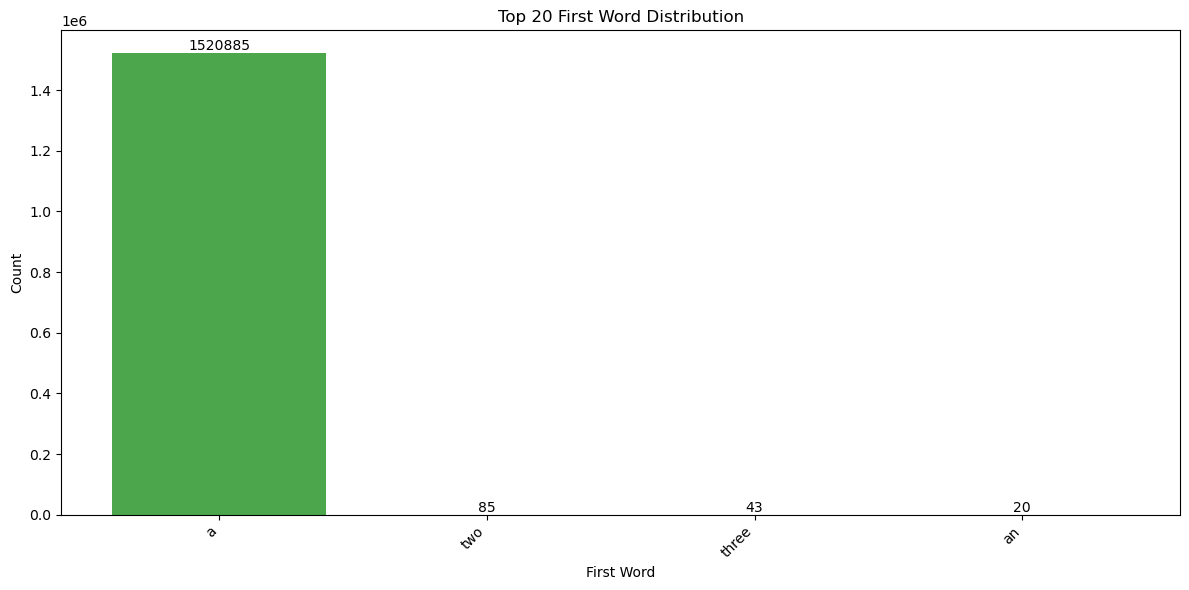

In [44]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def get_length_distribution(hf_dataset):
    """Get full distribution of description lengths."""
    descriptions = hf_dataset["description"]
    length_counts = Counter(len(desc) for desc in descriptions)
    return length_counts

def get_first_word_distribution(hf_dataset):
    """Get distribution of first words (case insensitive)."""
    descriptions = hf_dataset["description"]
    first_words = [desc.split()[0].lower() for desc in descriptions if desc]
    first_word_counts = Counter(first_words)
    return first_word_counts

def plot_length_distribution(length_counts):
    """Plot histogram of description length distribution."""
    lengths, counts = zip(*sorted(length_counts.items()))
    plt.figure(figsize=(10, 6))
    plt.bar(lengths, counts, color="blue", alpha=0.7)
    plt.title("Description Length Distribution")
    plt.xlabel("Length (characters)")
    plt.ylabel("Count")
    plt.show()

def plot_first_word_distribution(first_word_counts, top_n=20):
    """Plot bar chart of the top N first word distributions."""
    most_common = first_word_counts.most_common(top_n)
    words, counts = zip(*most_common)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(words, counts, color="green", alpha=0.7)
    plt.title(f"Top {top_n} First Word Distribution")
    plt.xlabel("First Word")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')

    # Add labels on top of bars
    for bar, count in zip(bars, counts):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, count, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# Example usage:
length_counts = get_length_distribution(preprocessed_dataset['train'])
first_word_counts = get_first_word_distribution(preprocessed_dataset['train'])
plot_length_distribution(length_counts)
plot_first_word_distribution(first_word_counts, top_n=20)


In [45]:
from datasets import DatasetDict

def push_dataset_to_hub(dataset: DatasetDict, repo_name: str, private: bool = False):
    """
    Uploads the given dataset to the Hugging Face Hub.

    Args:
        dataset (DatasetDict): The dataset to upload.
        repo_name (str): The name of the repository on the Hugging Face Hub.
        private (bool): Whether the repository should be private. Default is False.

    Returns:
        None
    """
    # Push the dataset to the Hugging Face Hub
    dataset.push_to_hub(repo_name, private=private)


In [ ]:
push_dataset_to_hub(preprocessed_dataset, "namfam/text2svg-v1-1.5m", private=False)


Uploading the dataset shards:   0%|          | 0/9 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/170 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/170 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/170 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/170 [00:00<?, ?ba/s]